In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
import seaborn as sns
colors = sns.color_palette()

import urllib.request
import os
def download(
    url : str,
    local_filename : str = None
):
    """Download a file from a url.
    
    Arguments
    url            -- The url we want to download.
    local_filename -- The filemame to write on. If not
                      specified 
    """
    if local_filename is None:
        local_filename = os.path.basename(url)
    urllib.request.urlretrieve(url, local_filename)

In [2]:
# BOOK_FIGURE_STYLE_CELL
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

try:
    import seaborn as sns
except ImportError:
    sns = None

try:
    import matplotlib_inline

    matplotlib_inline.backend_inline.set_matplotlib_formats("svg")
except Exception:
    matplotlib_inline = None

FIGURE_SIZES = {
    "full_landscape": (7.35, 4.40),
    "full_standard": (7.35, 4.90),
    "full_tall": (7.35, 5.50),
    "half_standard": (3.55, 2.55),
    "half_tall": (3.55, 3.05),
    "inset": (2.30, 1.75),
}

BOOK_COLORS = {
    "blue": "#4C78A8",
    "orange": "#F58518",
    "green": "#54A24B",
    "red": "#E45756",
    "gray": "#7F7F7F",
}

BOOK_TARGET = "web"


def setup_book_style(target="web"):
    global BOOK_TARGET
    BOOK_TARGET = target
    mpl.rcParams.update(
        {
            "figure.figsize": FIGURE_SIZES["half_standard"],
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.02,
            "font.family": "sans-serif",
            "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
            "axes.labelsize": 9,
            "axes.titlesize": 9,
            "axes.linewidth": 0.8,
            "axes.grid": False,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "xtick.labelsize": 8,
            "ytick.labelsize": 8,
            "xtick.major.width": 0.8,
            "ytick.major.width": 0.8,
            "legend.fontsize": 8,
            "legend.frameon": False,
            "lines.linewidth": 1.5,
            "lines.markersize": 4,
            "patch.linewidth": 0.8,
            "image.cmap": "viridis",
        }
    )
    if target == "latex":
        try:
            mpl.rcParams["text.usetex"] = False
        except Exception:
            mpl.rcParams["text.usetex"] = False


def new_figure(
    size="half_standard",
    nrows=1,
    ncols=1,
    sharex=False,
    sharey=False,
    constrained=True,
    squeeze=True,
    **kwargs,
):
    fig, ax = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        sharex=sharex,
        sharey=sharey,
        constrained_layout=constrained,
        figsize=FIGURE_SIZES[size],
        squeeze=squeeze,
        **kwargs,
    )
    return fig, ax


def label_panels(axes=None, labels=None, x=0.02, y=0.98, **kwargs):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    if labels is None:
        labels = [f"({chr(97 + i)})" for i in range(len(axes))]
    default = dict(
        fontsize=9,
        fontweight="semibold",
        va="top",
        ha="left",
        transform=None,
    )
    default.update(kwargs)
    for ax, label in zip(axes, labels):
        call_kwargs = dict(default)
        if call_kwargs["transform"] is None:
            call_kwargs["transform"] = ax.transAxes
        ax.text(x, y, label, **call_kwargs)


def finalize_axes(axes=None, keep_box=False, grid=False):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        if grid:
            ax.grid(axis="y", color="0.88", linewidth=0.6)
        else:
            ax.grid(False)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
        if keep_box:
            ax.spines["top"].set_visible(True)
            ax.spines["right"].set_visible(True)
        else:
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
    return axes


def save_book_figure(fig, basename, target="web", pdf=True, png=False):
    base = Path(basename)
    base.parent.mkdir(parents=True, exist_ok=True)
    if pdf:
        fig.savefig(base.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    if png:
        fig.savefig(base.with_suffix(".png"), bbox_inches="tight", pad_inches=0.02)


setup_book_style(target="web")


# Example - Ornstein-Uhlenbeck Process




We are going to consider the Ornstein-Uhlenbeck process, given as:

$$
dX_t = -\lambda(X_t - \mu)dt + \sigma dW_t
$$

where $X_t$ is the process, $\lambda$ is the rate of mean reversion, $\mu$ is the mean of the process, $\sigma$ is the volatility of the process, $W_t$ is the Wiener process.

In [3]:
%pip install optax

/Users/ebilionis/Dropbox/PredictiveScienceLab/mybooks/me697-book/advanced-scientific-machine-learning/.venv/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import datetime
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import jax.random as jr
import optax

As an example, we consider the 2-year Treasury note yield. A 2-year Treasury note is debt issued by the United States Department of the Treasury with a maturity of 2 years. Its yield is the return an investor would receive by holding the note until maturity, expressed as a percentage of the note's face value. This rate is influenced by Federal Reserve monetary policy, inflation, and demand for U.S. Treasury notes. Its sensitivity to monetary policy can produce volatile behavior. 

We fit the Ornstein--Uhlenbeck process as the yield rate recovers from the COVID-19-induced recession. In finance, this interest-rate model is known as the Vasicek model {cite:p}`vasicek1977equilibrium`.

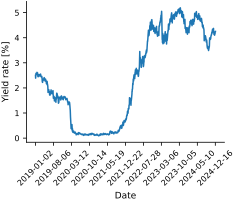

In [5]:
# Import two year T-bill data
url = 'https://github.com/PredictiveScienceLab/advanced-scientific-machine-learning/raw/refs/heads/main/book/data/twoYearTnote.csv'
download(url)
data = pd.read_csv("twoYearTnote.csv")
# remove nans
data = data.dropna()
raw_date = data['observation_date']
rate = data['DGS2']

# Plot the data with only 10 x axis ticks
plt.plot(raw_date, rate)
plt.xlabel("Date")
plt.ylabel("Yield rate [%]")
plt.xticks(ticks=plt.xticks()[0][::len(raw_date)//10], rotation=45)
finalize_axes(keep_box=False)
plt.show()

You can see how in March 2020 the yield rate dropped significantly due to the COVID-19 pandemic, and then it started to recover about 18 months later.

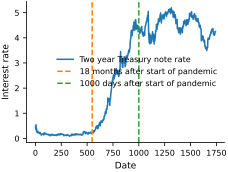

In [6]:
# Define Key dates
covid_start = '2020_03-12' # black thursday
recovery_start = '2021_09-12'

# Convert to datetime
covid_start = datetime.datetime.strptime(covid_start, "%Y_%m-%d")
recovery_start = datetime.datetime.strptime(recovery_start, "%Y_%m-%d")
recovery_start = (recovery_start - covid_start).days
date = pd.to_datetime(raw_date)
date = date - covid_start
date = date.dt.days
date = date.values

# Start data at the start of the pandemic
date_mask = date > 0
date = date[date_mask]
rate = rate[date_mask]

date = jnp.array(date, dtype=float)
rate = jnp.array(rate, dtype=float)

# Plot the data
plt.plot(date, rate, label='Two year Treasury note rate')
plt.axvline(recovery_start, color=colors[1], linestyle='--', label='18 months after start of pandemic')
plt.axvline(x=1000, color=colors[2], linestyle='--', label='1000 days after start of pandemic')
plt.xlabel("Date")
plt.ylabel("Interest rate")
plt.legend()
finalize_axes(keep_box=False)
plt.show()

We will call the rate at the beginning of the recovery $X_0$ and for round number sake, it appears that the rate has "recovered" about 1000 days after the market crash. We want to define this recovery so that we can empirically define the $\mu$, the mean that the process is reverting to. From here we will find the best parameters for the Ornstein-Uhlenbeck process that fits the data.

In [7]:
# Find the mean of rate until the beginning of the recovery
recovery_index = jnp.argmax(date >= recovery_start)
x0 = jnp.mean(rate[recovery_index])
mu = jnp.mean(rate[1000:])

print(f'The start of the process is {x0:.4}%')
print(f'The mean of the rate after 1000 days is {mu:.4}%')

# Make the data to start at the recovery index
recovery_days = date[recovery_index:] - recovery_start
recovery_rates = rate[recovery_index:]

The start of the process is 0.21%
The mean of the rate after 1000 days is 4.358%


Now that we have established $X_0$ and $\mu$, we can fit the mean-reversion parameter $\lambda$. The expectation of the process is

$$
\mathbb{E}[X_t] = X_0 e^{-\lambda t} + \mu (1 - e^{-\lambda t})
$$

We will just use a mean squared error loss function with a gradient descent optimizer to find the best $\lambda$ fit the data.

In [8]:
def exp_X(x0, mu, theta, t):
    return x0 * jnp.exp(-theta * t) + mu * (1 - jnp.exp(-theta * t))

def compute_loss(lam, X, t, x0, mu):
    # Calculate the expected value of X_t based on the Ornstein-Uhlenbeck process
    X_expected = exp_X(x0, mu, lam, t)
    # Calculate the mean squared error between observed X and expected X
    return jnp.mean((X - X_expected) ** 2)

# Create a function to fit the mean reversion parameter
def find_lam(X, t, x0, mu, lam0=1.0, learning_rate=0.01, max_iters=5000, tol=1e-3):
    # Initialize lam
    lam = jnp.array(lam0)
    # Define the optimizer
    optimizer = optax.adam(learning_rate)
    opt_state = optimizer.init(lam)

    # Optimization loop
    def step(lam, opt_state):
        # Compute the gradient of the loss with respect to lam
        loss, grad_loss = jax.value_and_grad(compute_loss)(lam, X, t, x0, mu)
        # Apply optimizer step
        updates, opt_state = optimizer.update(grad_loss, opt_state)
        lam = optax.apply_updates(lam, updates)
        return lam, opt_state, loss

    # Iterative optimization
    loss_evolution = []
    for i in range(max_iters):
        lam, opt_state, loss = step(lam, opt_state)
        loss_evolution.append(loss)
        # Check for convergence
        if loss < tol:
            print(f"Converged in {i} iterations")
            break

    return float(lam), jnp.array(loss_evolution)

We estimate $\lambda$ numerically. The optimizer and its starting point can be varied to assess the stability of the fitted value.

In [9]:
# Scaling the days to be between 0 and 1 for numerical stability
end_day = jnp.max(recovery_days)
s_days = recovery_days / end_day

# Fit the mean reversion parameter
lam, loss_evolution = find_lam(recovery_rates, s_days, x0, mu)

print(f"The estimated mean reversion parameter is {lam:.4}")

The estimated mean reversion parameter is 5.226


Okay, we have found a parameter, let's check the loss to make sure that our optimizer converged.

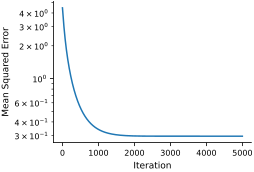

In [10]:
# Plot the loss evolution in log scale
plt.plot(loss_evolution)
plt.xlabel("Iteration")
plt.ylabel("Mean Squared Error")
plt.yscale('log')
finalize_axes(keep_box=False)
plt.show()

Great, we have converged. Let's do a sanity check and plot the expected value of the process against the data.

array([<Axes: xlabel='Scaled days since start of recovery', ylabel='Scaled rate'>],
      dtype=object)

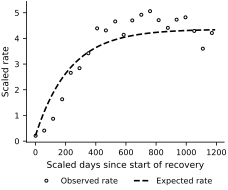

In [11]:
# Plot the expected value of X_t based on the Ornstein-Uhlenbeck process
t = jnp.linspace(0, 1, 100)
X_expected = exp_X(x0, mu, lam, t)
plt.plot(recovery_days, recovery_rates, color='black', linestyle='none',
         marker='o', markerfacecolor='white', markeredgecolor='black',
         markersize=3, markevery=max(1, len(recovery_days) // 20),
         label='Observed rate')
plt.plot(t*end_day, X_expected, color='black', linestyle='--', linewidth=1.6,
         label='Expected rate')
plt.xlabel("Scaled days since start of recovery")
plt.ylabel("Scaled rate")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.20), ncol=2)
finalize_axes(keep_box=False)

Okay, that looks plausible. Now let's find the volatility parameter $\sigma$. The variance of the process is

$$
\mathbb{V}[X_t] = \frac{\sigma^2}{2\lambda}(1 - e^{-2\lambda t})
$$

Now as time goes to infinity, the variance of the process should converge to $\frac{\sigma^2}{2\lambda}$. We can estimate our variance at the mean that we have empirically defined. We can then find the best $\sigma$ that fits the data.

In [12]:
def estimate_sigma(var, lam, t):
    return jnp.sqrt((2 * lam * var) / 1 - jnp.exp(-2 * lam * t))

# Estimate the variance of the rate after the recovery
X_var = jnp.var(recovery_rates[len(recovery_rates)//2:])
                
# Estimate the volatility sigma
sigma = estimate_sigma(X_var, lam, end_day)
print(f"The estimated volatility parameter is {sigma:.4}")

The estimated volatility parameter is 1.311


Okay, now all that's left is to simulate the process like we did for the stochastic exponential growth in the last notebook. We will again use the Euler-Maruyama discretization scheme. Notice the drift term is really the only thing that has changed.

In [13]:
# Create a function to simulate the Ornstein-Uhlenbeck process
def ou_step(carry, dt):
    key, mu, lam, sigma, x = carry
    key, subkey = jr.split(key)
    # Compute the drift term
    drift = lam * (mu - x) * dt
    # Compute the diffusion term
    diffusion = sigma * jnp.sqrt(dt) * jr.normal(subkey)
    # Compute the new value of X
    x_new = x + drift + diffusion
    return (key, mu, lam, sigma, x_new), x_new

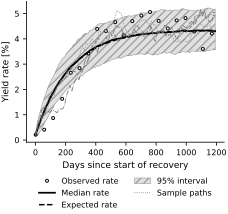

In [14]:
# Run a statstically significant number of simulations
n_samples = 1000
# Initialize the random number generator
sim_keys = jr.split(jr.PRNGKey(0), n_samples)
dt = jnp.diff(t)

all_Xt = []

# Simulate the Ornstein-Uhlenbeck process
for i in range(n_samples):
    init_carry = (sim_keys[i], mu, lam, sigma, x0)
    _, X_simulated = jax.lax.scan(ou_step, init_carry, dt)
    Xt = jnp.concatenate((jnp.array([x0]), X_simulated))
    all_Xt.append(Xt)

all_Xt = jnp.array(all_Xt)

X_median = jnp.median(all_Xt, axis=0)
X_lower = jnp.quantile(all_Xt, 0.025, axis=0)
X_upper = jnp.quantile(all_Xt, 0.975, axis=0)

# Plot the expected value of X_t based on the Ornstein-Uhlenbeck process
plt.plot(recovery_days, recovery_rates, color='black', linestyle='none',
         marker='o', markerfacecolor='white', markeredgecolor='black',
         markersize=3, markevery=max(1, len(recovery_days) // 20),
         label='Observed rate')
plt.plot(t*end_day, X_median, color='black', linestyle='-', linewidth=1.7,
         label='Median rate')
plt.plot(t*end_day, X_expected, color='black', linestyle='--', linewidth=1.5,
         label='Expected rate')
plt.fill_between(t*end_day, X_lower, X_upper, facecolor='0.88',
                 edgecolor='0.55', hatch='///', linewidth=0.5, label='95% interval')
# Plot some samples
sample_styles = [':', '-.', (0, (5, 2))]
for i in range(3):
    plt.plot(t*end_day, all_Xt[i], color='0.45', linestyle=sample_styles[i],
             linewidth=0.8, label='Sample paths' if i == 0 else None)
plt.xlabel("Days since start of recovery")
plt.ylabel("Yield rate [%]") 
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.20), ncol=2)
finalize_axes(keep_box=False)
plt.show()

The derived expectation agrees with the median of the simulations, and most observations lie within the simulated interval. The sample paths capture the main evolution of the yield rate. 

The model will not be perfect as the yield rate is influenced by many factors, including the monetary policy set by the Federal reserve, but it is a good start to understanding the behavior of the yield rate.

Vary the starting point and recovery time, or fit the model to another series such as the 10-year Treasury note yield from the Federal Reserve Economic Data (FRED) database {cite:p}`fred`.